### **Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

In [1]:
# loading data
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("mirichoi0218/insurance")
df = pd.read_csv(path + "/insurance.csv")

/workspaces/week_8/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


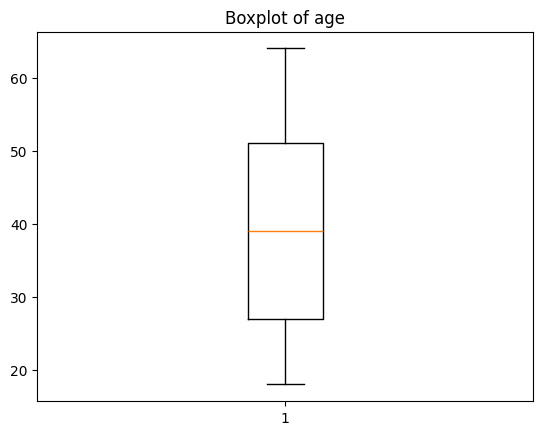

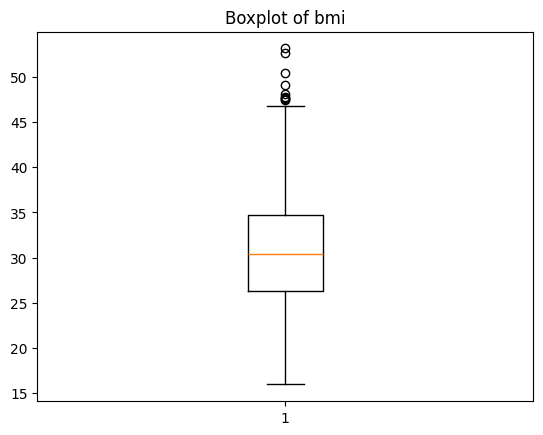

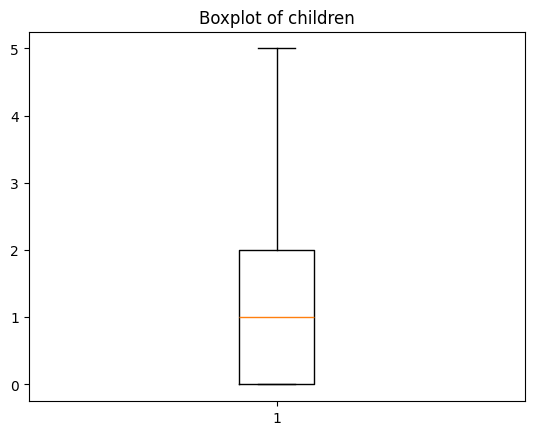

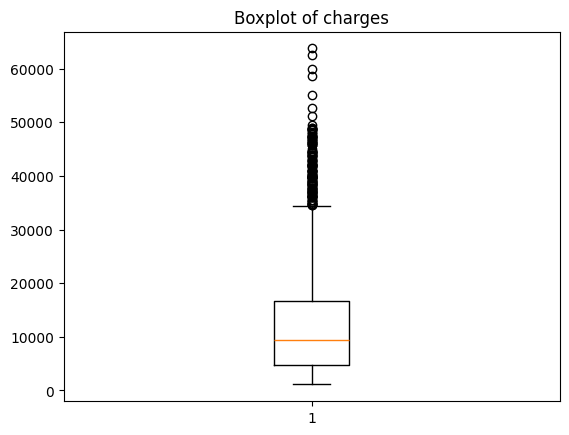

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# visualize the distribution of numeric columns using boxplots

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [6]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
# encode categorical variables and create a new column for log-transformed charges
df['is_smoker'] = pd.get_dummies(df['smoker'], drop_first=True)
df['is_female'] = pd.get_dummies(df['sex'], drop_first=True)
df['log_charges'] = np.log1p(df['charges'])

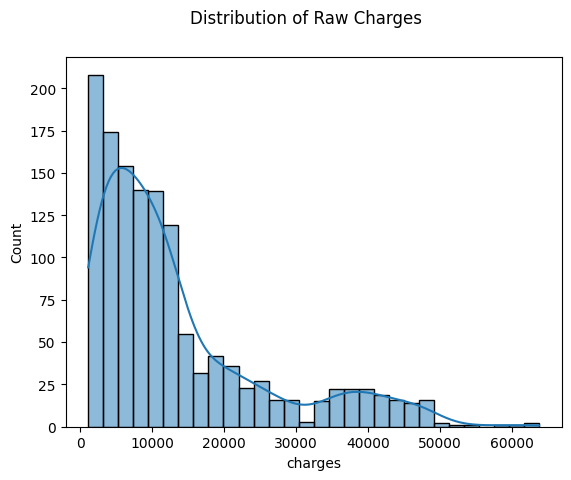

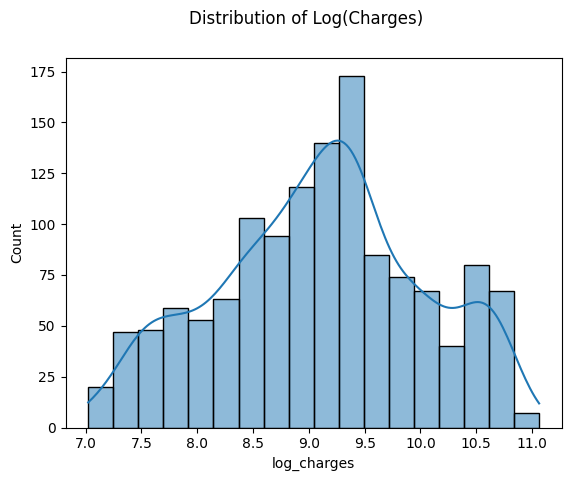

In [8]:
# compare the distribution of raw charges and log-transformed charges using histograms
sns.histplot(df['charges'], kde=True)
plt.suptitle('Distribution of Raw Charges')
plt.show()

sns.histplot(df['log_charges'], kde=True)
plt.suptitle('Distribution of Log(Charges)')
plt.show()

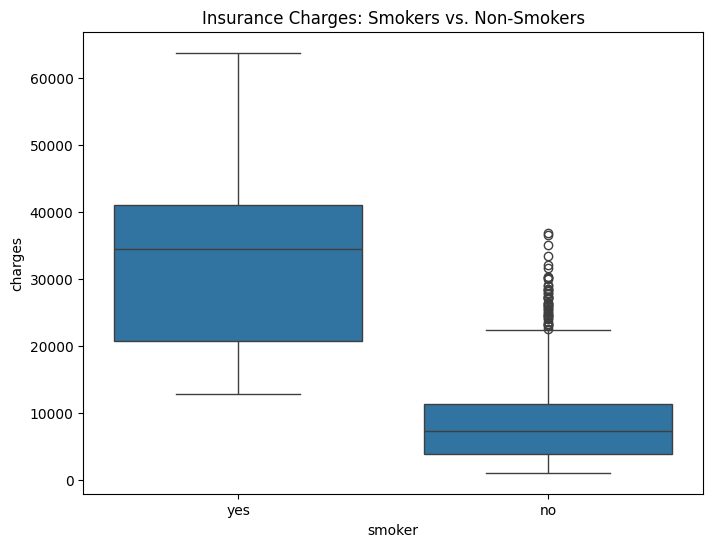

In [9]:
# explore the relationship between smoking status and insurance charges using boxplots
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Insurance Charges: Smokers vs. Non-Smokers')
plt.show()

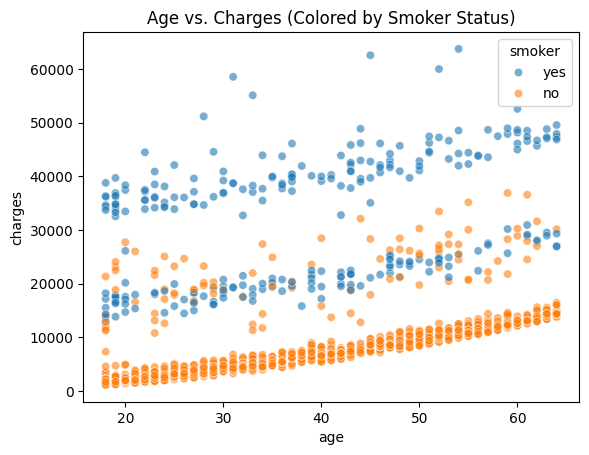

In [10]:
# explore relationship between age and charges
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title('Age vs. Charges (Colored by Smoker Status)')
plt.show()

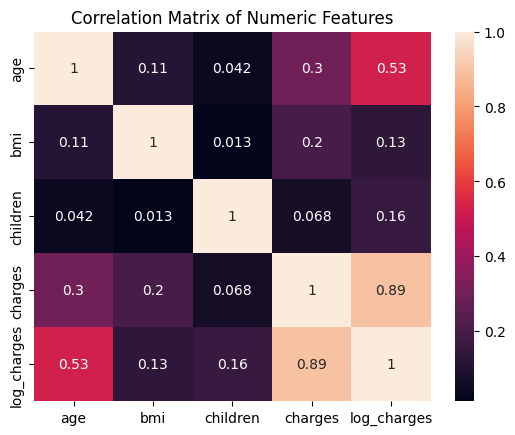

In [11]:
# correlation matrix of numeric features
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# build a linear regression model

X = df[['age', 'bmi', 'is_smoker']]
y = df['log_charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

In [13]:
# model A: using only age as a predictor

X_train_A = X_train[['age']]
X_test_A = X_test[['age']]
y_train_A = y_train
y_test_A = y_test

model_A = LinearRegression().fit(X_train_A, y_train_A)
preds_A = model_A.predict(X_test_A)
rmse_A = np.sqrt(mean_squared_error(y_test_A, preds_A))
print(f'Model A RMSE: {rmse_A}')

Model A RMSE: 0.8091369523641819


In [14]:
# model B: using age and bmi as predictors 
X_train_B = X_train[['age', 'bmi']]
X_test_B = X_test[['age', 'bmi']]
y_train_B = y_train
y_test_B = y_test

model_B = LinearRegression().fit(X_train_B, y_train_B)
preds_B = model_B.predict(X_test_B)
rmse_B = np.sqrt(mean_squared_error(y_test_B, preds_B))
print(f'Model B RMSE: {rmse_B}')

Model B RMSE: 0.8048034987425304


In [15]:
# model C: using age, bmi, and smoking status as predictors

X_train_C = X_train[['age', 'bmi', 'is_smoker']]
X_test_C = X_test[['age', 'bmi', 'is_smoker']]
y_train_C = y_train
y_test_C = y_test

model_C = LinearRegression().fit(X_train_C, y_train_C)
preds_C = model_C.predict(X_test_C)
rmse_C = np.sqrt(mean_squared_error(y_test_C, preds_C))
print(f'Model C RMSE: {rmse_C}')

Model C RMSE: 0.48122254389432195


I found that the model that performed the best was Model C. This is likely because model C incorporated all the main features that affect the insurance charge. This can be understood by the RMSE which dropped significantly after the addition of the 'smoker' variable to the model. The smoker feature, also, in general raises insurance charges a lot in comparison to something like children because of the addition health costs it will bring which lines up with the models predicitions.

I learned how a log transformation can normalize a distribution to make the model more stable and accurate. In this dataset, the charges were extremely skewed to the right and had a lot of outliers which was fixed through the log transformation. I also learned the impact different features and adding more features can bring to a model. By adding the 'smoker' feature, the RSME went down by around 0.32 showing a significant improvement in the model. I think this highlights the importance of figuring out what variables are affecting the target variable in order to create the best model.